## Swapnil Srivastava -12510029

### Problem 5

### Parameter Sweep on Decision Trees

### The objective is to perform a parameter sweep to optimize a Decision Tree Classifier based on two parameters:

#### $Size$: Controls the complexity of the tree (mapped to min_samples_leaf to control the minimum size of leaves).

#### $Purity$: Controls the stopping condition for splits ,as there is no custom parameter in sklearn to measure the node purty we have implemented a custom function for the same
-----
$Key Tasks:$

#### 1)Train trees on every combination of Size (10-100) and Purity (60-95).

#### 2)Log the training and testing accuracy in tree_sweep.csv.

#### 3)Identify the Optimal Tree (highest test accuracy).

#### 4)Extract Rules: Automatically generate the IF-THEN rules for the optimal tree.

#### 5)Visualize: (Conceptual) - Plot accuracy curves for Size (fixed at optimal purity) and Purity (fixed at optimal size) to see the trade-off between overfitting and underfitting.
------

### Step 1)Import the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Step 2)Extract the data

In [2]:
df=pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


### Step 3) Split the data in to test and train bucket

In [4]:
train_df,test_df=train_test_split(df,test_size=0.3,random_state=42)
train_df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5921,p,x,s,b,t,f,f,c,b,h,...,f,w,w,p,w,o,p,h,v,u
1073,e,x,f,g,t,n,f,c,b,p,...,s,p,w,p,w,o,p,k,y,d
3710,p,x,f,g,f,f,f,c,b,p,...,k,n,b,p,w,o,l,h,v,d
144,e,x,y,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,k,n,g
5469,p,x,y,n,f,y,f,c,n,b,...,k,w,p,p,w,o,e,w,v,d


### Step 4) Encoding the Categorical Columns

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
train_df_y = train_df['class'].copy()
train_df_x = train_df.drop('class',axis=1).copy()
train_df_encoded = train_df_x.copy()
test_df_y = test_df['class'].copy()
test_df_x = test_df.drop('class',axis=1).copy()
test_df_encoded = test_df_x.copy()

categorical_cols = train_df_x.select_dtypes(include=[np.object_]).columns
for col in categorical_cols:
	le = LabelEncoder()
	train_df_encoded[col] = le.fit_transform(train_df_x[col])
	test_df_encoded[col] = le.fit_transform(test_df_x[col])

train_df_encoded.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5921,5,2,0,1,2,1,0,0,3,1,...,0,7,7,0,2,1,4,1,4,5
1073,5,0,3,1,5,1,0,0,7,1,...,2,6,7,0,2,1,4,2,5,0
3710,5,0,3,0,2,1,0,0,7,0,...,1,4,0,0,2,1,2,1,4,0
144,5,3,9,1,0,1,0,0,4,0,...,2,7,7,0,2,1,4,2,2,1
5469,5,3,4,0,8,1,0,1,0,1,...,1,7,6,0,2,1,0,7,4,0


### Step 5) Create a custome function for Purity threashold

#### As there is no custom function to set the node puriy in sklearn ,I have implimented a custom class ,by creating a decision tree with the given min number of node and then pruning the nodes till we reach the required purity level at the leaf node
#### the class contains 4 functions
##### 1) fit-calls the DecisionTreeClassifier from sklearn taking min_samples_leaf as parameter
##### 2) _prune- it checks if for any given node if the purty is more than the desired purity it deletes the child nodes and make it leaf node

Size Sweep: Controlled by min_samples_leaf during training.

Purity Sweep: Controlled by your custom pruning function applied after training.

In [6]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin


class PurityThresholdTree(BaseEstimator, ClassifierMixin):
    """
    Decision Tree using sklearn, but pruned using a custom purity threshold:
    Stop splitting when majority class proportion >= purity_threshold (%).
    """

    def __init__(self, min_samples_leaf, purity_threshold):
        self.min_samples_leaf = min_samples_leaf
        self.purity_threshold = purity_threshold / 100  # convert 80% → 0.80

    def fit(self, X, y):
        self.feature_names_ = (
            X.columns if hasattr(X, "columns") else np.arange(X.shape[1])
        )

        # normal sklearn tree (unpruned)
        self.clf = DecisionTreeClassifier(
            criterion="entropy",
            min_samples_leaf=self.min_samples_leaf,
            random_state=0
        )
        self.clf.fit(X, y)

        # prune using purity threshold
        self._prune(self.clf.tree_, 0)

        return self

    def _prune(self, tree, node_id):
        # if leaf → nothing to prune
        if tree.children_left[node_id] == -1:
            return

        # majority class ratio at this node
        counts = tree.value[node_id][0]
        majority_ratio = counts.max() / counts.sum()

        # if satisfies purity threshold → make leaf
        if majority_ratio >= self.purity_threshold:
            tree.children_left[node_id] = -1
            tree.children_right[node_id] = -1
            tree.feature[node_id] = -2
            return

        # else recurse down both children
        self._prune(tree, tree.children_left[node_id])
        self._prune(tree, tree.children_right[node_id])

    def predict(self, X):
        return self.clf.predict(X)

    def get_rules(self):
        return export_text(self.clf, feature_names=list(self.feature_names_))


### Step 6) Create Function to Create a Decision tree with the given parameters


In [7]:
def tree_sweep(train_X, train_y, test_X, test_y,
               size_list=[10,20,30,40,50,60,70,80,90,100],
               purity_list=[60,65,70,75,80,85,90,95]):

    results = []

    for size in size_list:
        for purity in purity_list:

            model = PurityThresholdTree(
                min_samples_leaf=size,
                purity_threshold=purity
            )
            model.fit(train_X, train_y)

            train_acc = accuracy_score(train_y, model.predict(train_X))
            test_acc = accuracy_score(test_y, model.predict(test_X))

            results.append([size, purity, train_acc, test_acc])

    df = pd.DataFrame(results,
        columns=['size', 'purity', 'train_accuracy', 'test_accuracy'])

    df.to_csv("tree_sweep.csv", index=False)
    return df


### Step 7 )
#### a)Plot the  Purity Vs Accuracy graph (keeping at optimal size of the tree)
#### b)Plot the  Size Vs Accuracy graph (keeping at optimal purity of the tree)

In [8]:
import matplotlib.pyplot as plt

def plot_accuracy_vs_purity(df, optimal_size):
    temp = df[df['size'] == optimal_size]

    plt.figure(figsize=(7,5))
    plt.plot(temp['purity'], temp['train_accuracy'], marker='o', label="Train")
    plt.plot(temp['purity'], temp['test_accuracy'], marker='o', label="Test")
    plt.title(f"Purity vs Accuracy (size={optimal_size})")
    plt.xlabel("Purity threshold (%)")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.legend()
    plt.show()


def plot_accuracy_vs_size(df, optimal_purity):
    temp = df[df['purity'] == optimal_purity]

    plt.figure(figsize=(7,5))
    plt.plot(temp['size'], temp['train_accuracy'], marker='o', label="Train")
    plt.plot(temp['size'], temp['test_accuracy'], marker='o', label="Test")
    plt.title(f"Size vs Accuracy (purity={optimal_purity})")
    plt.xlabel("Size (min_sample_leaf)")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.legend()
    plt.show()


### Step 8 Find the Optimal Tree

In [9]:
def find_optimal(df):
    return df.loc[df['test_accuracy'].idxmax()]


### Step 9 Plot Build Optimal tree based on optimal Parameter :: Size & Purity

In [10]:
def build_optimal_tree(best, train_X, train_y):
    size = int(best['size'])
    purity = int(best['purity'])

    model = PurityThresholdTree(
        min_samples_leaf=size,
        purity_threshold=purity
    )
    model.fit(train_X, train_y)

    print("\nOptimal tree rules:\n")
    print(model.get_rules())

    return model


## Step 10  Call functions :
   #### Tree model
   #### Find the Optimal Tree
   #### Build optimal tree using the output from step 2
   #### Plot Graphs
  plot_accuracy_vs_purity  plot_accuracy_vs_size

size              10.000000
purity            95.000000
train_accuracy     0.985403
test_accuracy      0.986464
Name: 7, dtype: float64

Optimal tree rules:

|--- gill-color <= 0.50
|   |--- class: p
|--- gill-color >  0.50
|   |--- spore-print-color <= 1.50
|   |   |--- odor <= 3.50
|   |   |   |--- class: p
|   |   |--- odor >  3.50
|   |   |   |--- class: e
|   |--- spore-print-color >  1.50
|   |   |--- gill-size <= 0.50
|   |   |   |--- class: e
|   |   |--- gill-size >  0.50
|   |   |   |--- odor <= 5.50
|   |   |   |   |--- odor <= 2.00
|   |   |   |   |   |--- stalk-shape <= 0.50
|   |   |   |   |   |   |--- class: p
|   |   |   |   |   |--- stalk-shape >  0.50
|   |   |   |   |   |   |--- class: e
|   |   |   |   |--- odor >  2.00
|   |   |   |   |   |--- stalk-surface-below-ring <= 2.50
|   |   |   |   |   |   |--- class: e
|   |   |   |   |   |--- stalk-surface-below-ring >  2.50
|   |   |   |   |   |   |--- class: p
|   |   |   |--- odor >  5.50
|   |   |   |   |--- class: 

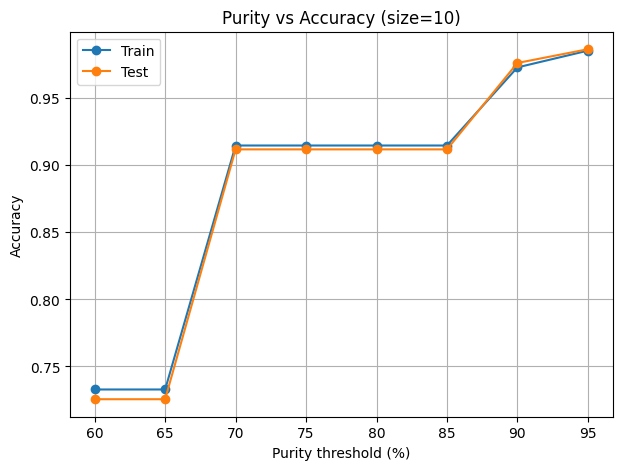

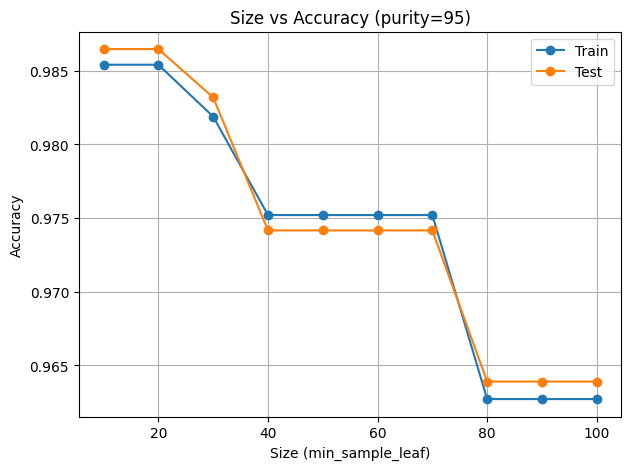

,size,purity,train_accuracy,test_accuracy
0,10,60,0.732853,0.725595
1,10,65,0.732853,0.725595
2,10,70,0.914703,0.911813
3,10,75,0.914703,0.911813
4,10,80,0.914703,0.911813
5,10,85,0.914703,0.911813
6,10,90,0.972916,0.976210
7,10,95,0.985403,0.986464
8,20,60,0.732853,0.725595
9,20,65,0.732853,0.725595


In [11]:
# correct argument ordering: tree_sweep(train_X, train_y, test_X, test_y)
df = tree_sweep(train_df_encoded, train_df_y, test_df_encoded, test_df_y)

best = find_optimal(df)
print(best)

# build_optimal_tree expects (best, train_X, train_y)
model = build_optimal_tree(best, train_df_encoded, train_df_y)

# ensure size/purity passed as integers
plot_accuracy_vs_purity(df, int(best['size']))
plot_accuracy_vs_size(df, int(best['purity']))
df.head(20)

### Outcome Summary:
----
#### 1. Optimal Model Performance
The parameter sweep successfully identified an optimal configuration for the decision tree:

##### Optimal Size (min_samples_leaf): 10

##### Optimal Purity Threshold: 95%

##### Training Accuracy: ~98.54%

##### Test Accuracy: ~98.65%

---

#### $Insight$: The fact that the test accuracy (98.65%) is slightly higher than the training accuracy (98.54%) indicates the model generalizes exceptionally well and is not overfitting.
---

#### 2. Interpretation of the Purity Graph
##### The "Purity vs. Accuracy" plot (at fixed Size=10) reveals a clear trend:

##### Low Purity (60-65%): Accuracy is poor (~73%), suggesting the tree is underfitting (stopping too early).

##### Medium Purity (70-85%): There is a massive jump in performance to ~91% accuracy.

##### High Purity (90-95%): The model performs best here, reaching >98%. This suggests that forcing the tree to split until nodes are very pure (95% of one class) captures the necessary complexity of the data without noise.
----
#### 3. Interpretation of the Size Graph
##### The "Size vs. Accuracy" graph (for fixed purity=95) shows that as you increase the leaf size (forcing simpler trees), accuracy drops:

##### Size 10-20: High accuracy (>98.5%).

##### Size > 40: Performance degrades rapidly to ~97.5%.

##### Size > 80: Accuracy drops further to ~96.3%.
---
#### 4. Generated Decision Rules
The optimal tree uses the following features to classify the samples (likely mushrooms, given features like "gill-color" and "odor"):

Root Split: gill-color is the most important feature. If gill-color <= 0.50, it immediately classifies as class 'p' (likely poisonous).

Secondary Features: For other cases, it checks spore-print-color, odor, gill-size, and stalk-shape.

#### Specific Rule Example:

IF gill-color > 0.50

AND spore-print-color <= 1.50

AND odor > 3.50

THEN Class 'e' (likely edible).

